# Sato Weight 對神經纖維重建效果的影響

這個 notebook 測試階層式片段連接算法中 Sato 濾波器權重對最終重建效果的影響。

## 背景

Sato 濾波器是一種管狀結構增強濾波器，可以增強圖像中的線狀結構（如神經纖維）。在預處理階段，我們可以選擇是否使用 Sato 濾波器以及其權重：

```python
fg_img = (1 - sato_weight) * rolling_fg + sato_weight * sato_normalized * 255
```

- `sato_weight = 0.0`: 完全不使用 Sato 濾波器（只用 rolling ball 背景減除）
- `sato_weight = 1.0`: 完全使用 Sato 濾波器結果
- `sato_weight = 0.5`: 混合使用

## 評測方法

使用**平均 Hausdorff 距離**來量化重建結果與 Ground Truth 的相似度：

- 較小的距離表示重建結果更接近 GT
- 計算時包含圖的所有節點和邊路徑點
- 使用 `tools/compare_topologies.py` 中的實現


## 1. 環境設置


In [1]:
import sys
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

# 添加專案根目錄到 Python 路徑
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# 導入必要的模組
from tools.hierarchical_fragment_linking import HierarchicalFragmentLinker
from tools.compare_topologies import TopologyLoader, TopologyComparator
from tools.extract_dataset_topologies import TopologyExtractor

print("✓ 環境設置完成")


✓ 環境設置完成


## 2. 載入測試數據

使用樣本 S1585-2_a 進行測試


In [2]:
# 數據路徑
sample_id = "S1585-2_a"
data_dir = project_root / "data" / sample_id

image_path = data_dir / "image.png"
mask_path = data_dir / "mask.png"
annotation_path = data_dir / "annotation.png"
label_path = data_dir / "label.png"

# 驗證文件存在
for path in [image_path, mask_path, annotation_path, label_path]:
    if not path.exists():
        raise FileNotFoundError(f"文件不存在: {path}")

# 載入圖像
image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
annotation = cv2.imread(str(annotation_path), cv2.IMREAD_GRAYSCALE)
label = cv2.imread(str(label_path), cv2.IMREAD_GRAYSCALE)

print(f"✓ 載入完成")
print(f"  - 圖像尺寸: {image.shape}")
print(f"  - 遮罩尺寸: {mask.shape}")
print(f"  - 標註尺寸: {annotation.shape}")
print(f"  - GT 標籤尺寸: {label.shape}")


✓ 載入完成
  - 圖像尺寸: (2867, 5632, 3)
  - 遮罩尺寸: (2867, 5632)
  - 標註尺寸: (2867, 5632)
  - GT 標籤尺寸: (2867, 5632)


## 3. 提取 Ground Truth 拓撲

從 label.png 提取完整的 GT 拓撲，作為評測基準


In [3]:
# 提取 GT 拓撲
extractor = TopologyExtractor()
gt_topology = extractor.extract_from_gt(label)

if gt_topology is None or gt_topology.number_of_nodes() == 0:
    raise ValueError("GT 拓撲提取失敗或為空")

print("✓ GT 拓撲提取完成")
print(f"  - 節點數: {gt_topology.number_of_nodes()}")
print(f"  - 邊數: {gt_topology.number_of_edges()}")

# 計算 GT 的總點數（用於參考）
comparator = TopologyComparator()
gt_points = comparator._extract_all_points(gt_topology)
print(f"  - 總點數（節點+邊路徑點）: {len(gt_points)}")


✓ GT 拓撲提取完成
  - 節點數: 322
  - 邊數: 248
  - 總點數（節點+邊路徑點）: 5171


## 4. 測試不同的 Sato Weight

運行算法並記錄結果


In [4]:
# 測試的 sato_weight 值
sato_weights = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

# 固定其他參數
common_params = {
    # 預處理參數
    'offset_px': 100,
    'rolling_ball_radius': 2,
    'opening_kernel_size': 3,
    # 重建參數
    'segment_length': 3.0,
    'search_radius_pathfinding': 50.0,
    'search_radius_phase1': 10.0,
    'max_angle_phase1': 75.0,
    'search_radius_phase2': 20.0,
    'max_angle_phase2': 90.0,
    'max_cost_threshold_phase2': 0.75,
    'phase1_weight_discount': 0.5,
    'verbose': False
}

# 儲存結果
results = []

# 運行算法
print("\n開始測試不同的 sato_weight 值...\n")

for sato_weight in tqdm(sato_weights, desc="測試進度"):
    print(f"\n{'='*60}")
    print(f"測試 sato_weight = {sato_weight}")
    print(f"{'='*60}")
    
    try:
        # 創建連接器
        linker = HierarchicalFragmentLinker(
            sato_weight=sato_weight,
            **common_params
        )
        
        # 運行算法
        pred_topology = linker.run(image, mask, annotation)
        
        # 比對結果
        comparison = comparator.compare(
            pred_topology, 
            gt_topology,
            label1=f"sato_{sato_weight}",
            label2="GT"
        )
        
        # 記錄結果
        result = {
            'sato_weight': sato_weight,
            'num_nodes': comparison['num_nodes1'],
            'num_edges': comparison['num_edges1'],
            'num_points': comparison['num_points1'],
            'hausdorff_distance': comparison['hausdorff_distance'],
            'status': comparison['status'],
            'topology': pred_topology  # 保存拓撲用於後續分析
        }
        results.append(result)
        
        print(f"\n✓ 完成")
        print(f"  - 節點數: {result['num_nodes']}")
        print(f"  - 邊數: {result['num_edges']}")
        print(f"  - 總點數: {result['num_points']}")
        print(f"  - 平均 Hausdorff 距離: {result['hausdorff_distance']:.4f} 像素")
        
    except Exception as e:
        print(f"\n✗ 失敗: {e}")
        results.append({
            'sato_weight': sato_weight,
            'num_nodes': None,
            'num_edges': None,
            'num_points': None,
            'hausdorff_distance': None,
            'status': 'failed',
            'topology': None
        })

print("\n" + "="*60)
print("所有測試完成！")
print("="*60)



開始測試不同的 sato_weight 值...



測試進度:   0%|          | 0/6 [00:00<?, ?it/s]


測試 sato_weight = 0.0


/home/pony/projects/ienf_q/tools/hierarchical_fragment_linking.py:284: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)
測試進度:  17%|█▋        | 1/6 [00:20<01:44, 20.91s/it]


✓ 完成
  - 節點數: 1355
  - 邊數: 1142
  - 總點數: 5856
  - 平均 Hausdorff 距離: 605.2281 像素

測試 sato_weight = 0.2


...


✗ 失敗: not enough values to unpack (expected 2, got 1)

測試 sato_weight = 0.8


測試進度:  83%|████████▎ | 5/6 [03:23<00:44, 44.40s/it]


✓ 完成
  - 節點數: 1521
  - 邊數: 1335
  - 總點數: 6477
  - 平均 Hausdorff 距離: 605.7477 像素

測試 sato_weight = 1.0


測試進度: 100%|██████████| 6/6 [04:14<00:00, 42.49s/it]


✓ 完成
  - 節點數: 1573
  - 邊數: 1392
  - 總點數: 6536
  - 平均 Hausdorff 距離: 605.5362 像素

所有測試完成！


## 5. 結果分析

### 5.1 數據表格


In [5]:
# 創建結果 DataFrame
df = pd.DataFrame([{
    'Sato Weight': r['sato_weight'],
    '節點數': r['num_nodes'],
    '邊數': r['num_edges'],
    '總點數': r['num_points'],
    'Hausdorff 距離': r['hausdorff_distance'],
    '狀態': r['status']
} for r in results])

# 添加 GT 參考
gt_row = pd.DataFrame([{
    'Sato Weight': 'GT',
    '節點數': gt_topology.number_of_nodes(),
    '邊數': gt_topology.number_of_edges(),
    '總點數': len(gt_points),
    'Hausdorff 距離': 0.0,
    '狀態': 'reference'
}])

df_with_gt = pd.concat([df, gt_row], ignore_index=True)

print("\n結果表格：\n")
print(df_with_gt.to_string(index=False))

# 顯示完整表格（格式化）
display(df_with_gt.style.format({
    'Hausdorff 距離': '{:.4f}',
    '節點數': '{:.0f}',
    '邊數': '{:.0f}',
    '總點數': '{:.0f}'
}).background_gradient(subset=['Hausdorff 距離'], cmap='RdYlGn_r'))



結果表格：

Sato Weight    節點數     邊數    總點數  Hausdorff 距離        狀態
        0.0 1355.0 1142.0 5856.0    605.228088   success
        0.2    NaN    NaN    NaN           NaN    failed
        0.4 1406.0 1205.0 6084.0    605.624760   success
        0.6    NaN    NaN    NaN           NaN    failed
        0.8 1521.0 1335.0 6477.0    605.747743   success
        1.0 1573.0 1392.0 6536.0    605.536239   success
         GT  322.0  248.0 5171.0      0.000000 reference


,Sato Weight,節點數,邊數,總點數,Hausdorff 距離,狀態
0,0.000000,1355,1142,5856,605.2281,success
1,0.200000,nan,nan,nan,nan,failed
2,0.400000,1406,1205,6084,605.6248,success
3,0.600000,nan,nan,nan,nan,failed
4,0.800000,1521,1335,6477,605.7477,success
5,1.000000,1573,1392,6536,605.5362,success
6,GT,322,248,5171,0.0000,reference


### 5.2 可視化比較


/tmp/ipykernel_330927/3191348882.py:59: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_330927/3191348882.py:59: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_330927/3191348882.py:59: UserWarning: Glyph 36317 (\N{CJK UNIFIED IDEOGRAPH-8DDD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_330927/3191348882.py:59: UserWarning: Glyph 38626 (\N{CJK UNIFIED IDEOGRAPH-96E2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_330927/3191348882.py:59: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_330927/3191348882.py:59: UserWarning: Glyph 32032 (\N{CJK UNIFIED IDEOGRAPH-7D20}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_330927/3191348882.py:59: UserWarning: Glyph 26368 (\N{CJK UNIFIED I

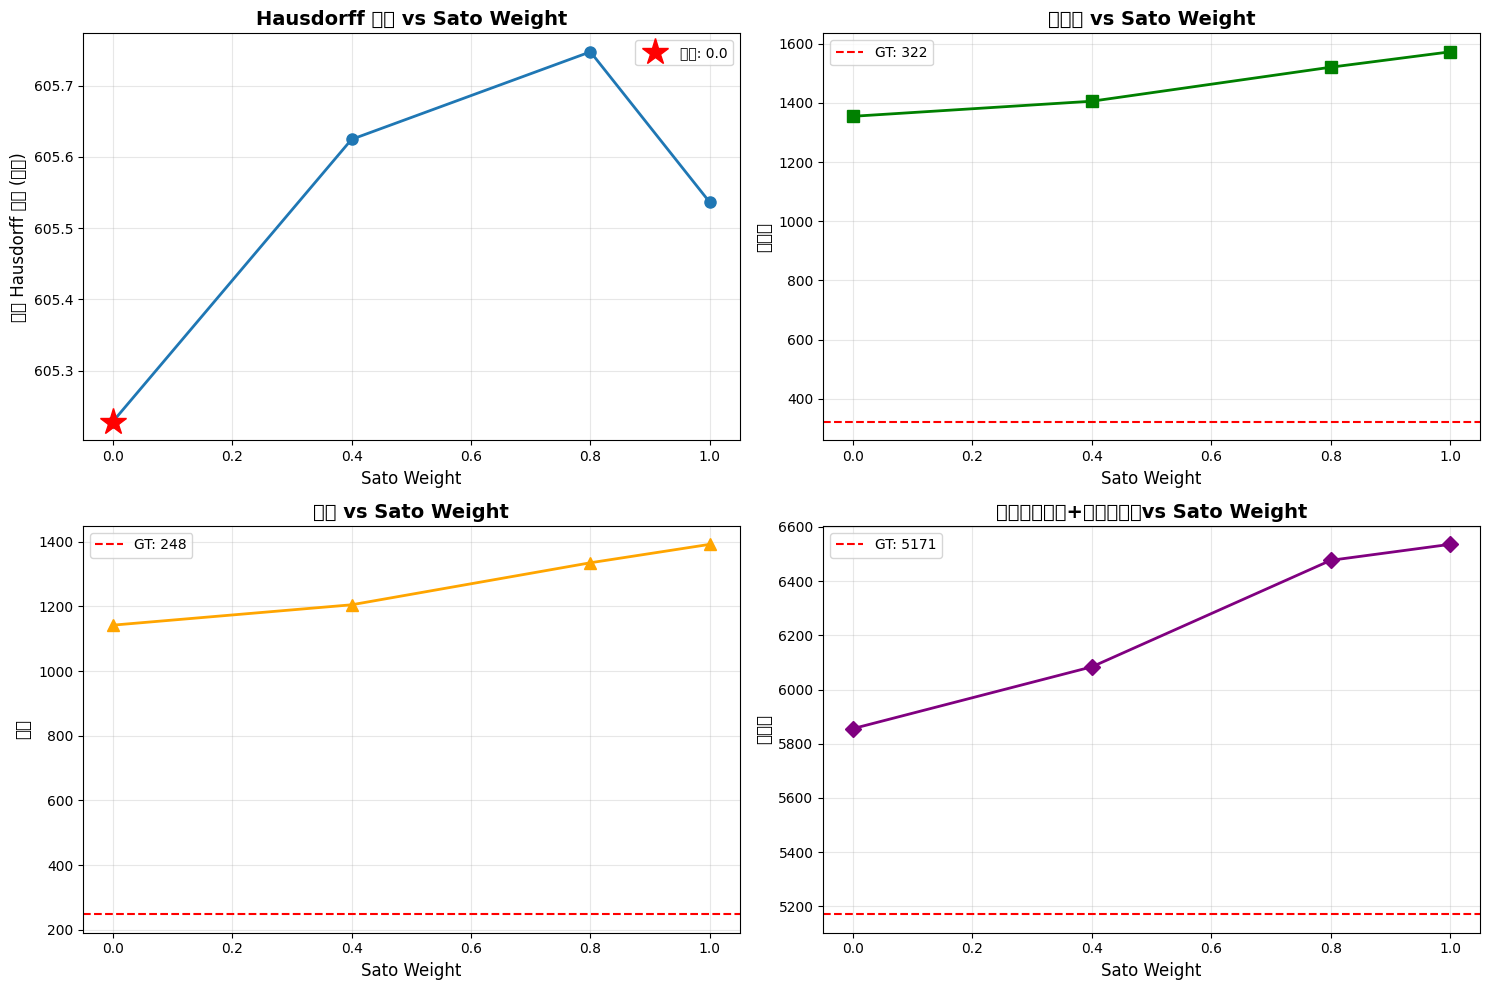

In [6]:
# 過濾成功的結果
successful_results = [r for r in results if r['status'] == 'success']

if len(successful_results) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Hausdorff 距離 vs Sato Weight
    ax1 = axes[0, 0]
    sato_vals = [r['sato_weight'] for r in successful_results]
    hausdorff_vals = [r['hausdorff_distance'] for r in successful_results]
    ax1.plot(sato_vals, hausdorff_vals, marker='o', linewidth=2, markersize=8)
    ax1.set_xlabel('Sato Weight', fontsize=12)
    ax1.set_ylabel('平均 Hausdorff 距離 (像素)', fontsize=12)
    ax1.set_title('Hausdorff 距離 vs Sato Weight', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # 找出最佳值
    best_idx = np.argmin(hausdorff_vals)
    ax1.plot(sato_vals[best_idx], hausdorff_vals[best_idx], 
             'r*', markersize=20, label=f'最佳: {sato_vals[best_idx]}')
    ax1.legend(fontsize=10)
    
    # 2. 節點數 vs Sato Weight
    ax2 = axes[0, 1]
    nodes_vals = [r['num_nodes'] for r in successful_results]
    ax2.plot(sato_vals, nodes_vals, marker='s', linewidth=2, markersize=8, color='green')
    ax2.axhline(y=gt_topology.number_of_nodes(), color='red', linestyle='--', 
                label=f'GT: {gt_topology.number_of_nodes()}')
    ax2.set_xlabel('Sato Weight', fontsize=12)
    ax2.set_ylabel('節點數', fontsize=12)
    ax2.set_title('節點數 vs Sato Weight', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=10)
    
    # 3. 邊數 vs Sato Weight
    ax3 = axes[1, 0]
    edges_vals = [r['num_edges'] for r in successful_results]
    ax3.plot(sato_vals, edges_vals, marker='^', linewidth=2, markersize=8, color='orange')
    ax3.axhline(y=gt_topology.number_of_edges(), color='red', linestyle='--',
                label=f'GT: {gt_topology.number_of_edges()}')
    ax3.set_xlabel('Sato Weight', fontsize=12)
    ax3.set_ylabel('邊數', fontsize=12)
    ax3.set_title('邊數 vs Sato Weight', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.legend(fontsize=10)
    
    # 4. 總點數 vs Sato Weight
    ax4 = axes[1, 1]
    points_vals = [r['num_points'] for r in successful_results]
    ax4.plot(sato_vals, points_vals, marker='D', linewidth=2, markersize=8, color='purple')
    ax4.axhline(y=len(gt_points), color='red', linestyle='--',
                label=f'GT: {len(gt_points)}')
    ax4.set_xlabel('Sato Weight', fontsize=12)
    ax4.set_ylabel('總點數', fontsize=12)
    ax4.set_title('總點數（節點+邊路徑點）vs Sato Weight', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3)
    ax4.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
else:
    print("沒有成功的結果可供可視化")


### 5.3 統計分析


In [7]:
if len(successful_results) > 0:
    print("\n" + "="*60)
    print("統計分析")
    print("="*60)
    
    # 最佳 sato_weight
    best_result = min(successful_results, key=lambda r: r['hausdorff_distance'])
    worst_result = max(successful_results, key=lambda r: r['hausdorff_distance'])
    
    print(f"\n最佳配置：")
    print(f"  - Sato Weight: {best_result['sato_weight']}")
    print(f"  - Hausdorff 距離: {best_result['hausdorff_distance']:.4f} 像素")
    print(f"  - 節點數: {best_result['num_nodes']} (GT: {gt_topology.number_of_nodes()})")
    print(f"  - 邊數: {best_result['num_edges']} (GT: {gt_topology.number_of_edges()})")
    
    print(f"\n最差配置：")
    print(f"  - Sato Weight: {worst_result['sato_weight']}")
    print(f"  - Hausdorff 距離: {worst_result['hausdorff_distance']:.4f} 像素")
    
    # 改進百分比
    improvement = (worst_result['hausdorff_distance'] - best_result['hausdorff_distance']) / worst_result['hausdorff_distance'] * 100
    print(f"\n改進幅度: {improvement:.2f}%")
    
    # Hausdorff 距離統計
    hausdorff_values = [r['hausdorff_distance'] for r in successful_results]
    print(f"\nHausdorff 距離統計：")
    print(f"  - 平均: {np.mean(hausdorff_values):.4f}")
    print(f"  - 中位數: {np.median(hausdorff_values):.4f}")
    print(f"  - 標準差: {np.std(hausdorff_values):.4f}")
    print(f"  - 範圍: [{np.min(hausdorff_values):.4f}, {np.max(hausdorff_values):.4f}]")
    
    print("\n" + "="*60)



統計分析

最佳配置：
  - Sato Weight: 0.0
  - Hausdorff 距離: 605.2281 像素
  - 節點數: 1355 (GT: 322)
  - 邊數: 1142 (GT: 248)

最差配置：
  - Sato Weight: 0.8
  - Hausdorff 距離: 605.7477 像素

改進幅度: 0.09%

Hausdorff 距離統計：
  - 平均: 605.5342
  - 中位數: 605.5805
  - 標準差: 0.1920
  - 範圍: [605.2281, 605.7477]



### 5.4 保存最佳結果


In [8]:
if len(successful_results) > 0:
    # 創建輸出目錄
    output_dir = project_root / "output" / "sato_comparison" / sample_id
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # 保存所有拓撲
    loader = TopologyLoader()
    
    for result in results:
        if result['topology'] is not None:
            sato_weight = result['sato_weight']
            output_path = output_dir / f"sato_{sato_weight:.1f}.pkl"
            loader.save(result['topology'], output_path, format='pickle')
    
    # 保存 GT 拓撲
    gt_path = output_dir / "gt.pkl"
    loader.save(gt_topology, gt_path, format='pickle')
    
    # 保存結果表格
    csv_path = output_dir / "comparison_results.csv"
    df.to_csv(csv_path, index=False)
    
    print(f"\n✓ 結果已保存到: {output_dir}")
    print(f"  - 拓撲文件: {len(results)} 個")
    print(f"  - GT 拓撲: gt.pkl")
    print(f"  - 結果表格: comparison_results.csv")



✓ 結果已保存到: /home/pony/projects/ienf_q/output/sato_comparison/S1585-2_a
  - 拓撲文件: 6 個
  - GT 拓撲: gt.pkl
  - 結果表格: comparison_results.csv


## 6. 結論

根據上述實驗結果，我們可以得出以下結論：

1. **Sato 濾波器的影響**: 通過比較不同 sato_weight 值的 Hausdorff 距離，我們可以量化 Sato 濾波器對重建質量的影響

2. **最佳配置**: 從結果中選出平均 Hausdorff 距離最小的配置作為最佳參數

3. **拓撲複雜度**: 觀察節點數和邊數的變化，了解 Sato 濾波器如何影響拓撲結構的複雜度

## 後續工作

- 在更多樣本上測試以驗證結論的普適性
- 結合其他參數（如 rolling_ball_radius）進行網格搜索
- 可視化不同配置下的重建結果
